# Эволюция стиля творчества Эдуарда Лимонова


**Идея проекта:** сравнить несколько TXT-файлов с произведениями Эдуарда Лимонова и посмотреть, как меняются ключевые слова, тематические маркеры и стилевые особенности текстов.


In [31]:
!pip install requests
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install nltk
!pip install razdel
!pip install pymorphy3
!pip install scikit-learn
!pip install scipy

import re
import math
from collections import Counter

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from razdel import tokenize
import pymorphy3

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import dendrogram, linkage

nltk.download('stopwords', quiet=True)

morph = pymorphy3.MorphAnalyzer()
stop_words = set(stopwords.words('russian'))

In [32]:


text_urls = {
    'Molod_Negodyai': 'https://raw.githubusercontent.com/antondobryj0-ui/limonov_data_set/refs/heads/main/LibramsRU_Молодой_негодяй.txt',
    'Savenko': 'https://raw.githubusercontent.com/antondobryj0-ui/limonov_data_set/refs/heads/main/LibramsRU_Подросток_Савенко.txt',
    'epoha': 'https://raw.githubusercontent.com/antondobryj0-ui/limonov_data_set/refs/heads/main/LibramsRU_У_нас_была_великая_эпоха.txt',
    'edichka': 'https://raw.githubusercontent.com/antondobryj0-ui/limonov_data_set/refs/heads/main/LibramsRU_Это_я_-_Эдичка.txt',
    'neudachnik': 'https://raw.githubusercontent.com/antondobryj0-ui/limonov_data_set/refs/heads/main/Эдуард_Лимонов_–_Дневник_неудачника_или_Секретная_тетрадь.txt',
    'slugi': 'https://raw.githubusercontent.com/antondobryj0-ui/limonov_data_set/refs/heads/main/Эдуард_Лимонов_–_История_его_слуги.txt'

}

corpus = {}

for title, url in text_urls.items():
    response = requests.get(url)
    response.encoding = 'utf-8'

    if response.status_code == 200:
        corpus[title] = response.text
    else:
        print(f'Не удалось загрузить: {title}')
        print(f'Статус: {response.status_code}')

print(f'Загружено текстов: {len(corpus)}')
print(list(corpus.keys()))

Не удалось загрузить: Molod_Negodyai
Статус: 404
Загружено текстов: 5
['Savenko', 'epoha', 'edichka', 'neudachnik', 'slugi']



 Проверка длины текстов


In [33]:
lengths = {}

for title, text in corpus.items():
    lengths[title] = len(text)

lengths_df = pd.DataFrame.from_dict(lengths, orient='index', columns=['length'])
lengths_df = lengths_df.sort_values('length', ascending=False)

lengths_df

,length
slugi,629215
edichka,603599
Savenko,442616
epoha,291970
neudachnik,186394


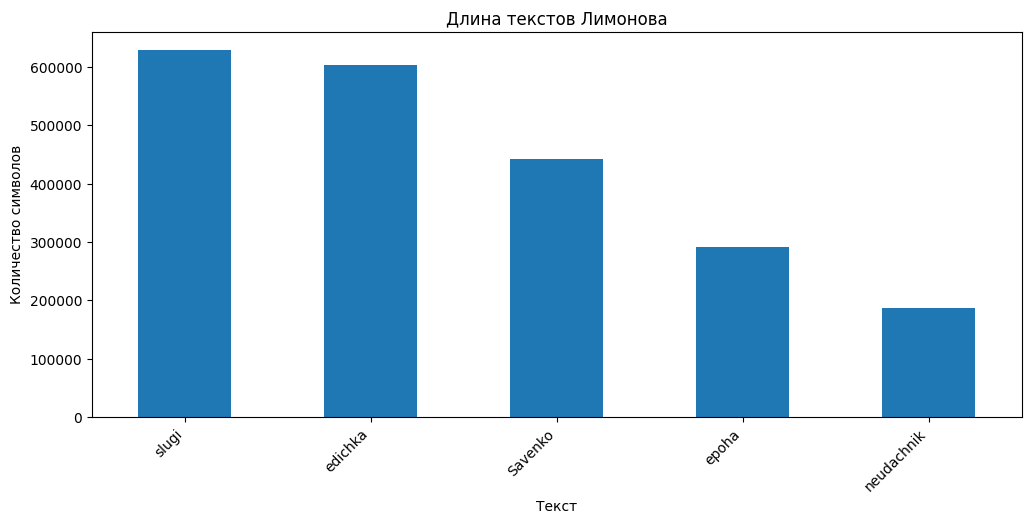

In [35]:
lengths_df.plot(kind='bar', figsize=(12, 5), legend=False)
plt.title('Длина текстов Лимонова')
plt.ylabel('Количество символов')
plt.xlabel('Текст')
plt.xticks(rotation=45, ha='right')
plt.show()

In [36]:
def preprocess(text):
    """Токенизирует, лемматизирует текст и убирает стоп-слова."""
    tokens = [token.text.lower() for token in tokenize(text)]

    lemmas = []

    for word in tokens:
        if re.fullmatch('[а-яё]+', word):
            lemma = morph.parse(word)[0].normal_form

            if lemma not in stop_words and len(lemma) > 3:
                lemmas.append(lemma)

    return lemmas

In [39]:
texts_by_title = {}
counts_by_title = {}

for title, text in corpus.items():
    lemmas = preprocess(text)
    texts_by_title[title] = lemmas
    counts_by_title[title] = Counter(lemmas)

df = pd.DataFrame(counts_by_title).fillna(0).astype(int)

print(f'Таблица: {df.shape[0]} лемм × {df.shape[1]} текстов')
df.head()

Таблица: 20409 лемм × 5 текстов


,Savenko,epoha,edichka,neudachnik,slugi
книга,59,29,48,24,211
мало,23,8,49,9,25
политика,3,1,2,0,6
интеллигентный,5,1,7,0,16
взгляд,15,16,37,10,33


##Самые частотные слова в каждом тексте

In [38]:
for title in df.columns:
    print(f'\n{title}')
    print(df[title].sort_values(ascending=False).head(20))


Savenko
свой        439
говорить    325
мочь        243
светка      238
мать        229
кадик       225
который     219
знать       216
ребята      200
весь        194
думать      185
рука        172
отец        171
очень       162
сказать     160
время       149
вовка       136
деньга      132
хотеть      127
человек     123
Name: Savenko, dtype: int64

epoha
мать         217
отец         216
мочь         151
ребёнок      140
свой         140
время        122
сказать      112
солдат       109
весь         104
рука          97
мама          94
эдик          86
автор         85
однако        80
лейтенант     80
человек       78
стать         77
военный       72
русский       72
который       69
Name: epoha, dtype: int64

edichka
свой        547
мочь        479
сказать     470
человек     387
который     346
весь        318
говорить    303
знать       301
очень       278
хотеть      270
елена       216
русский     213
думать      208
время       203
жить        189
жизнь       184
делат

##  TF-IDF: ключевые слова каждого текста




In [40]:
corpus_texts = {}

for title, lemmas in texts_by_title.items():
    corpus_texts[title] = ' '.join(lemmas)

titles_list = sorted(corpus_texts.keys())
texts_list = [corpus_texts[title] for title in titles_list]

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=russian_stop_words
)
tfidf_matrix = vectorizer.fit_transform(texts_list)

feature_names = vectorizer.get_feature_names_out()

print(f'Размер матрицы: {tfidf_matrix.shape}')

Размер матрицы: (5, 5000)


In [41]:
tfidf_results = {}

for i, title in enumerate(titles_list):
    row = tfidf_matrix[i].toarray().flatten()
    top_indices = row.argsort()[-15:][::-1]

    top_words = [(feature_names[j], round(row[j], 3)) for j in top_indices]
    tfidf_results[title] = top_words

    print(f'\n{title}:')
    for word, score in top_words:
        print(f'{word}: {score}')


Savenko:
светка: 0.293
кадик: 0.277
говорить: 0.236
мочь: 0.177
вовка: 0.167
мать: 0.166
знать: 0.157
славка: 0.148
ребята: 0.145
саня: 0.137
думать: 0.134
салтовский: 0.132
рука: 0.125
отец: 0.124
костя: 0.122

edichka:
мочь: 0.296
сказать: 0.291
человек: 0.239
говорить: 0.187
знать: 0.186
хотеть: 0.167
елена: 0.134
русский: 0.132
думать: 0.129
время: 0.126
жить: 0.117
кирилл: 0.115
жизнь: 0.114
делать: 0.112
розанна: 0.11

epoha:
мать: 0.275
отец: 0.274
мочь: 0.192
ребёнок: 0.178
малышня: 0.163
время: 0.155
сказать: 0.142
солдат: 0.138
рука: 0.123
лейтенант: 0.12
мама: 0.119
дивизия: 0.114
вениамин: 0.112
штаб: 0.109
эдик: 0.109

neudachnik:
человек: 0.19
жизнь: 0.188
мочь: 0.172
любить: 0.16
женщина: 0.147
друг: 0.147
экономка: 0.143
девочка: 0.136
говорить: 0.136
идти: 0.131
знать: 0.124
хотеть: 0.124
день: 0.122
хороший: 0.12
время: 0.106

slugi:
дженни: 0.496
стивен: 0.258
линда: 0.231
сказать: 0.222
гэтсби: 0.222
мочь: 0.198
время: 0.152
эдвард: 0.135
человек: 0.122
знать: 0.12

In [42]:
rows = []

for title, words in tfidf_results.items():
    for word, score in words:
        rows.append({
            'text': title,
            'word': word,
            'tfidf': score
        })

tfidf_df = pd.DataFrame(rows)
tfidf_df

,text,word,tfidf
0,Savenko,светка,0.293
1,Savenko,кадик,0.277
2,Savenko,говорить,0.236
3,Savenko,мочь,0.177
4,Savenko,вовка,0.167
...,...,...,...
70,slugi,жизнь,0.119
71,slugi,хотеть,0.115
72,slugi,думать,0.108
73,slugi,книга,0.104


In [44]:
# Сохранение таблицы с ключевыми словами
tfidf_df.to_csv('limonov_tfidf_keywords.csv', index=False, encoding='utf-8-sig')

## Стилометрия


In [45]:
def clean_for_stylometry(text):
    """Очищает текст для стилометрического анализа."""
    text = text.lower()
    text = re.sub('ё', 'е', text)
    text = re.sub('[^а-я\s]', ' ', text)
    text = re.sub('\s+', ' ', text)
    return text.strip()

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_29029/3257623763.py:5: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('[^а-я\s]', ' ', text)
/tmp/ipykernel_29029/3257623763.py:6: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('\s+', ' ', text)


In [46]:
cleaned_texts = {}

for title, text in corpus.items():
    cleaned_texts[title] = clean_for_stylometry(text)

first_title = list(cleaned_texts.keys())[0]
print(first_title)
print(cleaned_texts[first_title][:300])

Savenko
в этой книге мало политики в ней не интеллигентный взгляд на реальность а взгляд подростка рабочего подростка живущего среди людей его же социальной категории книжка получилась одновременно и живая и жесткая да в полном смысле политики там нет во всяком случае если она и есть то не в лоб как это был


In [47]:
titles_list = sorted(cleaned_texts.keys())
texts_list = [cleaned_texts[title] for title in titles_list]

russian_stop_words = list(stop_words) + [
    'это', 'этот', 'эта', 'эти', 'этого', 'этой', 'этом',
    'быть', 'был', 'была', 'было', 'были',
    'весь', 'вся', 'все', 'всё', 'всего',
    'который', 'которая', 'которое', 'которые',
    'свой', 'своя', 'свое', 'свои',
    'очень', 'просто', 'тоже', 'ещё', 'еще',
    'хочу', 'хочется',
    'эдуард'
]

vectorizer = CountVectorizer(
    max_features=100,
    stop_words=russian_stop_words
)
counts = vectorizer.fit_transform(texts_list)
words = vectorizer.get_feature_names_out()

counts_df = pd.DataFrame(
    counts.toarray(),
    index=titles_list,
    columns=words
)

counts_df.head()

,бэби,вместе,времени,время,глаза,говорил,говорит,года,гэтсби,давно,...,улице,хотел,хотя,хочет,хуй,хуя,часто,человек,эдвард,эди
Savenko,1006,59,25,120,30,20,223,29,0,42,...,24,21,104,55,52,20,14,49,0,1898
edichka,10,84,35,158,38,69,67,18,0,25,...,46,98,108,35,143,67,52,106,5,2
epoha,0,17,41,61,12,13,3,31,0,13,...,14,13,24,4,0,1,13,23,0,1
neudachnik,0,7,6,34,21,5,18,15,0,10,...,15,9,24,8,14,12,15,20,15,5
slugi,8,47,62,237,29,44,41,37,217,31,...,29,67,109,36,72,37,37,87,183,2


In [48]:

freq_df = counts_df.div(counts_df.sum(axis=1), axis=0)
freq_df.head()

,бэби,вместе,времени,время,глаза,говорил,говорит,года,гэтсби,давно,...,улице,хотел,хотя,хочет,хуй,хуя,часто,человек,эдвард,эди
Savenko,0.149148,0.008747,0.003706,0.017791,0.004448,0.002965,0.033062,0.004299,0.000000,0.006227,...,0.003558,0.003113,0.015419,0.008154,0.007709,0.002965,0.002076,0.007265,0.000000,0.281394
edichka,0.001761,0.014789,0.006162,0.027817,0.006690,0.012148,0.011796,0.003169,0.000000,0.004401,...,0.008099,0.017254,0.019014,0.006162,0.025176,0.011796,0.009155,0.018662,0.000880,0.000352
epoha,0.000000,0.009599,0.023151,0.034444,0.006776,0.007340,0.001694,0.017504,0.000000,0.007340,...,0.007905,0.007340,0.013552,0.002259,0.000000,0.000565,0.007340,0.012987,0.000000,0.000565
neudachnik,0.000000,0.005376,0.004608,0.026114,0.016129,0.003840,0.013825,0.011521,0.000000,0.007680,...,0.011521,0.006912,0.018433,0.006144,0.010753,0.009217,0.011521,0.015361,0.011521,0.003840
slugi,0.001167,0.006858,0.009047,0.034583,0.004232,0.006421,0.005983,0.005399,0.031665,0.004524,...,0.004232,0.009777,0.015905,0.005253,0.010506,0.005399,0.005399,0.012695,0.026704,0.000292


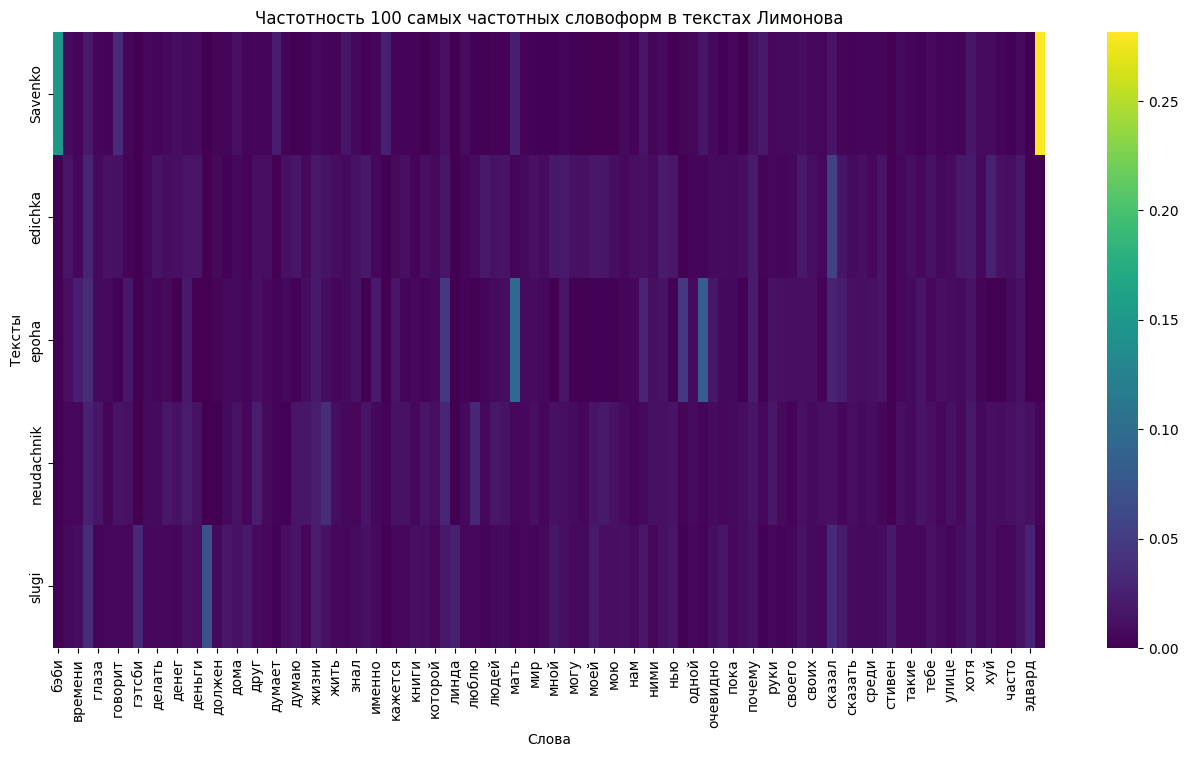

In [49]:
plt.figure(figsize=(16, 8))
sns.heatmap(freq_df, cmap='viridis')
plt.title('Частотность 100 самых частотных словоформ в текстах Лимонова')
plt.xlabel('Слова')
plt.ylabel('Тексты')
plt.show()

## Расстояние между текстами



In [50]:
distance_matrix = pairwise_distances(freq_df, metric='manhattan')

distance_df = pd.DataFrame(
    distance_matrix,
    index=titles_list,
    columns=titles_list
)

distance_df

,Savenko,edichka,epoha,neudachnik,slugi
Savenko,0.000000,1.166735,1.181651,1.130614,1.173584
edichka,1.166735,0.000000,0.814487,0.489939,0.542526
epoha,1.181651,0.814487,0.000000,0.820641,0.871202
neudachnik,1.130614,0.489939,0.820641,0.000000,0.643517
slugi,1.173584,0.542526,0.871202,0.643517,0.000000


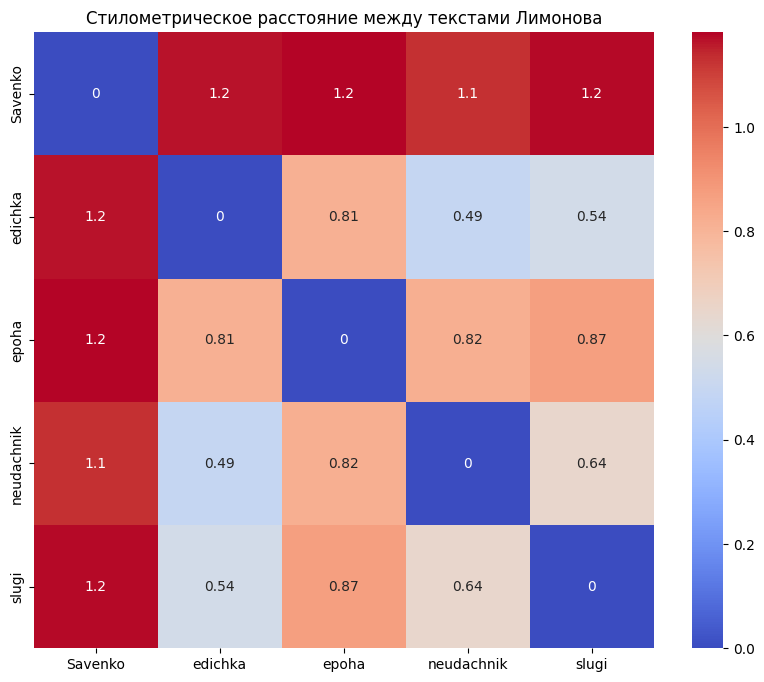

In [51]:
plt.figure(figsize=(10, 8))
sns.heatmap(distance_df, annot=True, cmap='coolwarm')
plt.title('Стилометрическое расстояние между текстами Лимонова')
plt.show()

## Дендрограмма



/tmp/ipykernel_29029/2308222252.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(distance_matrix, method='ward')


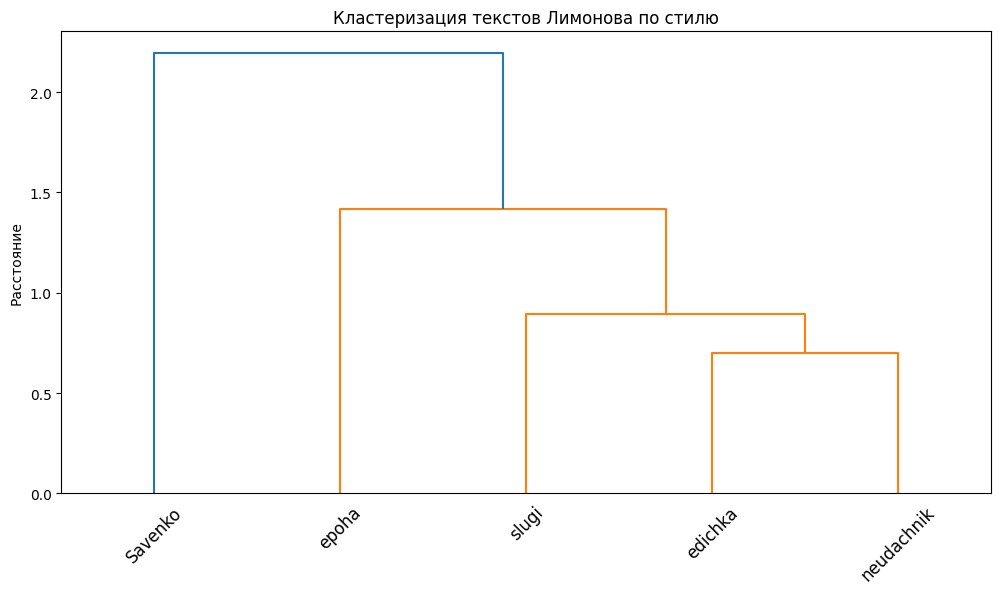

In [52]:
linked = linkage(distance_matrix, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, labels=titles_list, leaf_rotation=45)
plt.title('Кластеризация текстов Лимонова по стилю')
plt.ylabel('Расстояние')
plt.show()